## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import sys
import missingno
import re

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [3]:
dataset = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc)

In [4]:
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases
0,23.812763,38.047451,1,2010,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000,8.761039,11.580251,5.941828,0.578889,17.782222,10.733185,NaN,NaN,NaN,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,120.039680,25.307650,42.361009,47.792020,45883.000000,200375.000000,47279.000000,293537.000000,43595.000000,220412.000000,60276.000000,324283.000000,18689.140000,NaN,NaN,2164.888889,0
1,23.685082,38.018504,1,2010,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000,10.493728,13.860538,7.126918,1.052222,19.014444,12.935874,NaN,NaN,NaN,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,112.130405,23.686240,39.818155,44.482084,38921.000000,179791.000000,33796.000000,252508.000000,36714.000000,177899.000000,44828.000000,259441.000000,7131.890000,NaN,NaN,2596.888889,0
2,23.754944,37.979104,1,2010,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000,9.753346,12.876044,6.630647,0.379474,18.605789,11.901135,NaN,NaN,NaN,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,112.993420,23.831676,39.924151,44.652948,64868.000000,377784.000000,79042.000000,521694.000000,61544.000000,388717.000000,118883.000000,569144.000000,39021.830000,NaN,NaN,2375.526316,0
3,23.749555,37.914897,1,2010,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,20.666667,19.500000,42.391304,866.637529,44.000000,-2.000000,46.000000,9.833333,31.500000,31.500000,9.833333,779.000000,192.000000,0.000000,86.033662,317.000000,46.000000,46.000000,317.000000,9.072484,12.310000,5.834968,-2.668000,19.224000,11.720357,NaN,NaN,NaN,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,110.246915,23.460094,39.829571,44.335911,38993.000000,183267.000000,41033.000000,263293.000000,36789.000000,199070.000000,55549.000000,291408.000000,12606.740000,NaN,NaN,2468.400000,0
4,23.889386,38.042726,1,2010,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,0.397771,0.155384,-0.199277,-0.155384,0.399240,0.160357,-0.193923,-0.160357,0.037753,0.035591,0.039219,0.035591,19.416667,21.000000,47.727273,855.685088,44.000000,0.000000,44.000000,14.500000,30.500000,30.500000,9.333333,868.000000,219.000000,0.000000,83.901842,363.000000,71.000000,71.000000,342.000000,8.701736,11.589957,5.813515,1.772276,18.574390,10.720874,NaN,NaN,NaN,13.768236,NaN,NaN,NaN,7.672467,NaN,NaN,NaN,3.905487,121.070102,25.460487,41.766648,46.576365,

In [5]:
geomorphological = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [6]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.40559815950908545
Max distance: 29.592566110235495


In [7]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [8]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')
dataset.head()

,x,y,month,year,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.812763,38.047451,1,2010,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,19.750000,20.000000,45.454545,859.836137,44.000000,0.000000,44.000000,14.833333,30.833333,30.833333,9.333333,843.000000,213.000000,0.000000,83.792957,346.000000,70.000000,70.000000,332.000000,8.761039,11.580251,5.941828,0.578889,17.782222,10.733185,NaN,NaN,NaN,13.594339,NaN,NaN,NaN,7.872031,NaN,NaN,NaN,3.872248,120.039680,25.307650,42.361009,47.792020,45883.000000,200375.000000,47279.000000,293537.000000,43595.000000,220412.000000,60276.000000,324283.000000,18689.140000,NaN,NaN,2164.888889,0,14600.648385,292.022047,2,182.342684,228.131012,182.543294,0.000000,41.287682
1,23.685082,38.018504,1,2010,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,21.333333,20.500000,45.555556,895.781359,46.000000,1.000000,45.000000,15.666667,32.833333,32.833333,10.500000,806.000000,204.000000,0.000000,83.719908,324.000000,59.000000,59.000000,308.000000,10.493728,13.860538,7.126918,1.052222,19.014444,12.935874,NaN,NaN,NaN,16.635552,NaN,NaN,NaN,9.236196,NaN,NaN,NaN,3.617110,112.130405,23.686240,39.818155,44.482084,38921.000000,179791.000000,33796.000000,252508.000000,36714.000000,177899.000000,44828.000000,259441.000000,7131.890000,NaN,NaN,2596.888889,0,7655.023708,1575.096836,1,173.398830,66.866135,178.818040,0.000000,5.887334
2,23.754944,37.979104,1,2010,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,20.458333,19.583333,44.507576,856.116584,44.000000,0.000000,44.000000,15.500000,31.500000,31.500000,10.000000,800.000000,199.000000,0.000000,85.292444,324.000000,54.000000,54.000000,321.000000,9.753346,12.876044,6.630647,0.379474,18.605789,11.901135,NaN,NaN,NaN,14.995668,NaN,NaN,NaN,8.808187,NaN,NaN,NaN,3.644949,112.993420,23.831676,39.924151,44.652948,64868.000000,377784.000000,79042.000000,521694.000000,61544.000000,388717.000000,118883.000000,569144.000000,39021.830000,NaN,NaN,2375.526316,0,9967.604261,2195.498040,15,239.898712,262.905206,194.363331,0.000000,2.669538
3,23.749555,37.914897,1,2010,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,20.666667,19.500000,42.391304,866.637529,44.000000,-2.000000,46.000000,9.833333,31.500000,31.500000,9.833333,779.000000,192.000000,0.000000,86.033662,317.000000,46.000000,46.000000,317.000000,9.072484,12.310000,5.834968,-2.668000,19.224000,11.720357,NaN,NaN,NaN,14.676866,NaN,NaN,NaN,8.763849,NaN,NaN,NaN,3.556352,110.246915,23.460094,39.829571,44.335911,38993.000000,183267.000000,41033.000000,263293.000000,36789.000000,199070.000000,55549.000000,291408.000000,12606.740000,NaN,NaN,2468.400000,0,2801.690321,1232.926967,4,211.997473,80.771234,191.138144,0.000000,3.315736
4,23.889386,38.042726,1,2010,2010-01,EL30,αττικη,EL305,ανατολικη αττικη,0.397771,0.155384,-0.1992

<AxesSubplot:>

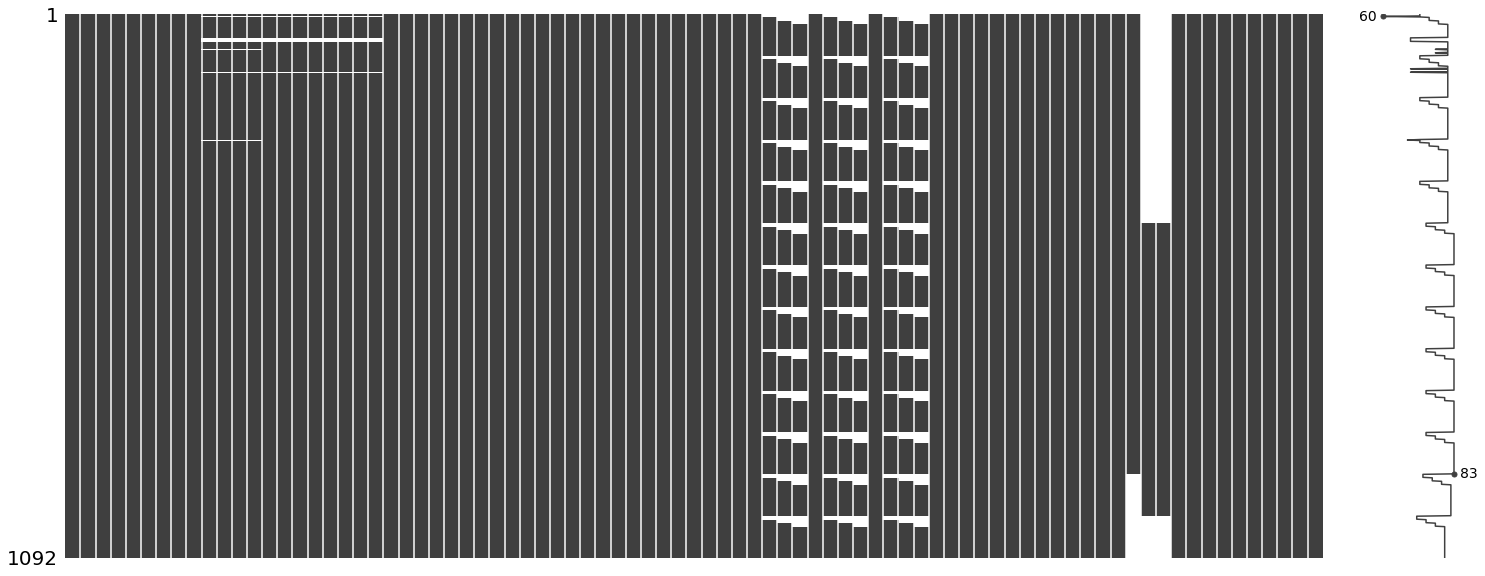

In [9]:
missingno.matrix(dataset)

In [10]:
cols = dataset.columns
cols

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [11]:
len(cols)

83

In [12]:
landcover = pd.read_csv(f'../../../../Greece/data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2021_filled.csv')
landcover.columns = landcover.columns.str.lower()

In [13]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [14]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [15]:
data_years = dataset['year'].unique().tolist()

In [16]:
for year in data_years:
    frame_name = f'dataset_{year}'
    locals()[frame_name] = dataset.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [17]:
for year in data_years:
    data_name = f'dataset_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_part_{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = df_lulc.append(locals()[lc_name].iloc[[index]])

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2010
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2011
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2012
Min distance: 0.40559815950908545
Max distance: 29.592566110235495
Year: 2013
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2014
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2015
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2016
Min distance: 0.40559815950908545
Max distance: 29.592566110235495
Year: 2017
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2018
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2019
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2020
Min distance: 0.40559815950908545
Max distance: 29.592566110235495
Year: 2021
Min distance: 0.4055981595092324
Max distance: 29.592566110235495
Year: 2022
Min distance: 0.4055981595092324
Max distance: 29.592566110235

In [18]:
dataset_final = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_part_{year}'
    dataset_final = pd.concat([dataset_final, locals()[merged_name]], ignore_index=True)

<AxesSubplot:>

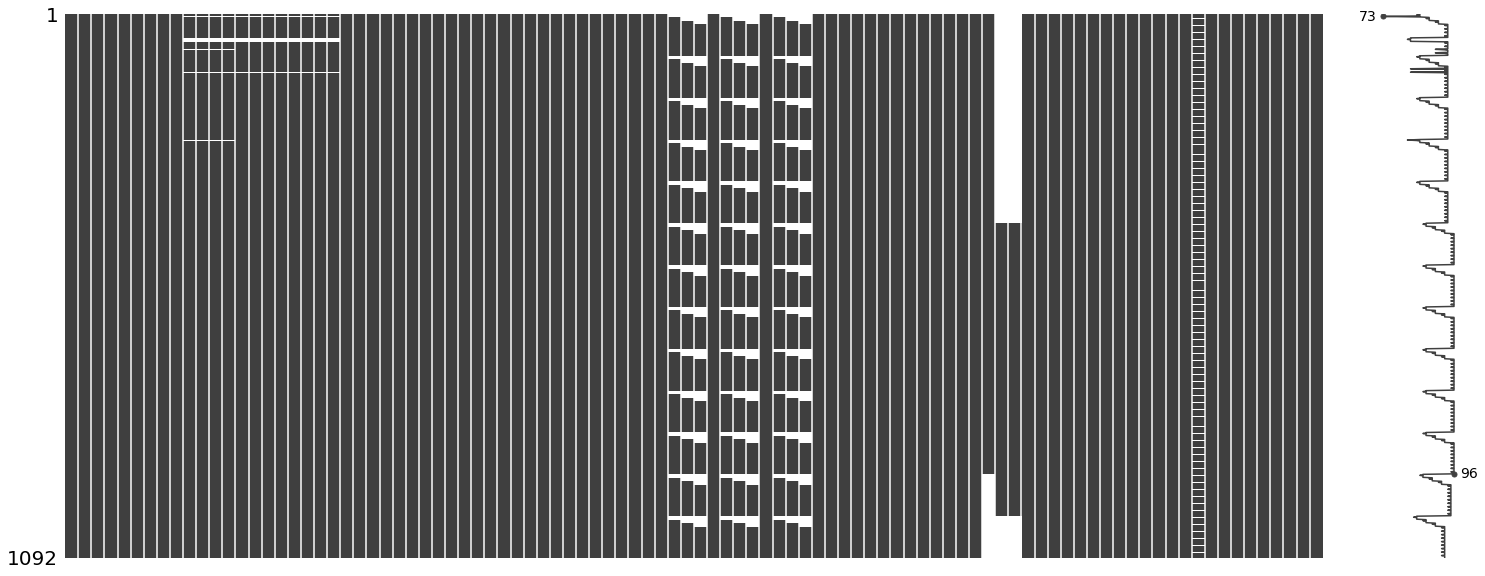

In [19]:
missingno.matrix(dataset_final)

In [20]:
cols = dataset_final.columns
cols

Index(['x', 'y', 'month', 'year', 'dt_placement', 'NUTS2_ID', 'NUTS2_NAME',
       'NUTS3_ID', 'NUTS3_NAME', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6',
       'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14',
       'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'lst', 'lst_day',
       'lst_night', 'monthly_lst_min', 'monthly_lst_max', 'lst_jan_mean',
       'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'lst_jan_day_mean',
       'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean',
       'lst_apr_night_mean', 'rainfall', 'monthly_acc_prec',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'M_Y_LT15', 'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64',
       'F_Y_GE65', 'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 

In [21]:
len(cols)

96

In [22]:
dataset_final.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc, index = False)